##  Load dữ liệu

In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv('classData.csv')
print("Kích thước:", df.shape)
df.head()

Kích thước: (7861, 10)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


## Tiền xử lý

In [21]:
# ===== Mapping lỗi =====
df['Fault_Type'] = (
    df['G'].astype(str) +
    df['C'].astype(str) +
    df['B'].astype(str) +
    df['A'].astype(str)
)

fault_mapping = {
    '0000': 'No Fault',
    
    # Lỗi 1 pha chạm đất (Single Line to Ground)
    '1000': 'Single Line to Ground A',
    '0100': 'Single Line to Ground B',
    '0010': 'Single Line to Ground C',
    
    # Lỗi 2 pha (Line-to-Line)
    '0011': 'Line-to-Line BC',
    '0101': 'Line-to-Line AC',
    '1001': 'Line-to-Line AB',
    
    # Lỗi 2 pha chạm đất (Line-to-Line with Ground)
    '1010': 'Line-to-Line with Ground AB',
    '1101': 'Line-to-Line with Ground AC', 
    '0110': 'Line-to-Line with Ground BC',
    '1011': 'Line A Line B to Ground Fault', 
    
    # Lỗi 3 pha (Three-Phase)
    '0111': 'Three-Phase',
    '1111': 'Three-Phase with Ground'
}

df['Fault_Label'] = df['Fault_Type'].map(fault_mapping)

# Bỏ mẫu không map được
df = df.dropna(subset=['Fault_Label'])

# ===== X, y =====
feature_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X = df[feature_cols]
y = df['Fault_Label']

## Train / Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Mô hình Baseline - RF

In [23]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "f1_macro": f1_score(y_test, baseline_pred, average='macro'),
    "precision_macro": precision_score(y_test, baseline_pred, average='macro'),
    "recall_macro": recall_score(y_test, baseline_pred, average='macro'),
}

In [25]:
import joblib

baseline_artifacts = {
    "model": baseline_model,
    "feature_cols": feature_cols,
    "metrics": baseline_metrics,
    "test_size": 0.2,
    "random_state": 42
}

joblib.dump(baseline_artifacts, "rf_baseline.pkl")
print("Đã lưu Model")

Đã lưu Model


## Trực quan và Đánh giá Baseline

In [26]:
from sklearn.metrics import accuracy_score, classification_report

print("=== BASELINE ACCURACY ===")
print(accuracy_score(y_test, baseline_pred))

print("\n=== BASELINE REPORT ===")
print(classification_report(y_test, baseline_pred))

=== BASELINE ACCURACY ===
0.8811188811188811

=== BASELINE REPORT ===
                               precision    recall  f1-score   support

Line A Line B to Ground Fault       1.00      1.00      1.00       227
              Line-to-Line AB       1.00      1.00      1.00       226
  Line-to-Line with Ground BC       1.00      1.00      1.00       201
                     No Fault       1.00      1.00      1.00       473
                  Three-Phase       0.58      0.59      0.58       219
      Three-Phase with Ground       0.59      0.58      0.58       227

                     accuracy                           0.88      1573
                    macro avg       0.86      0.86      0.86      1573
                 weighted avg       0.88      0.88      0.88      1573



### Các đặc trưng quan trọng

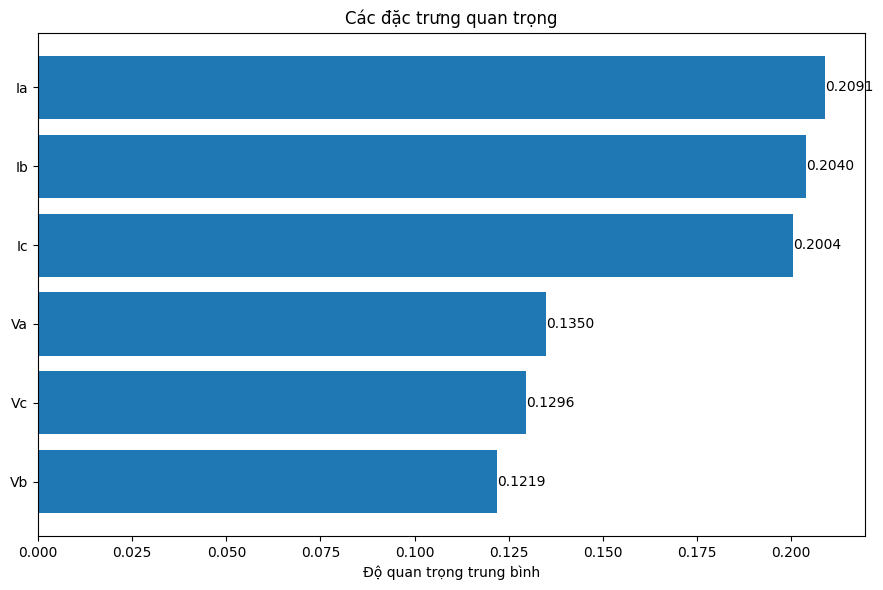

In [27]:
import numpy as np
import matplotlib.pyplot as plt

all_importances = np.array([
    est.feature_importances_
    for est in baseline_model.estimators_
])

mean_importances = all_importances.mean(axis=0)
indices = np.argsort(mean_importances)

plt.figure(figsize=(9, 6))
bars = plt.barh(
    [feature_cols[i] for i in indices],
    mean_importances[indices]
)

plt.xlabel("Độ quan trọng trung bình")
plt.title("Các đặc trưng quan trọng")

# Hiện số trên từng thanh
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### ROC Curve

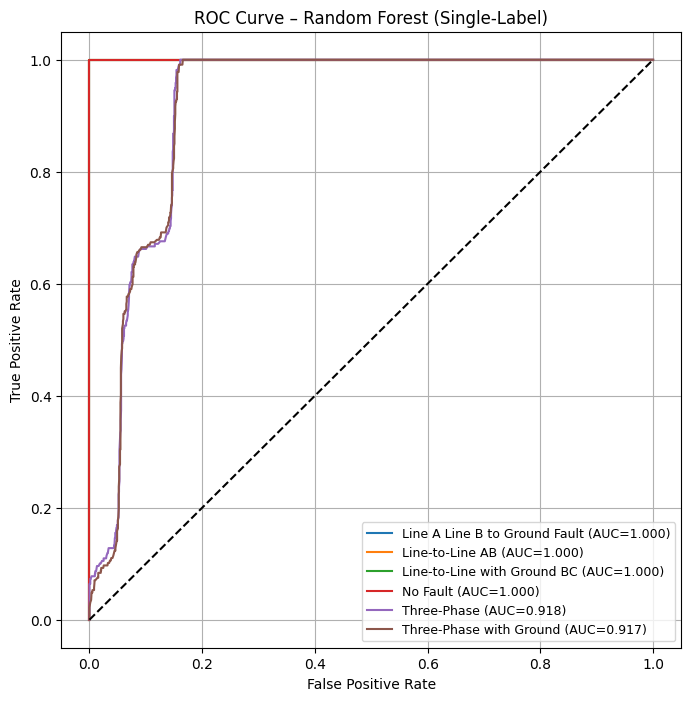

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(
    y_test,
    classes=baseline_model.classes_
)

y_score = baseline_model.predict_proba(X_test)

plt.figure(figsize=(8,8))

for i, cls in enumerate(baseline_model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest (Single-Label)")
plt.legend(fontsize=9)
plt.grid(True)
plt.show()

### Confusion Matrix

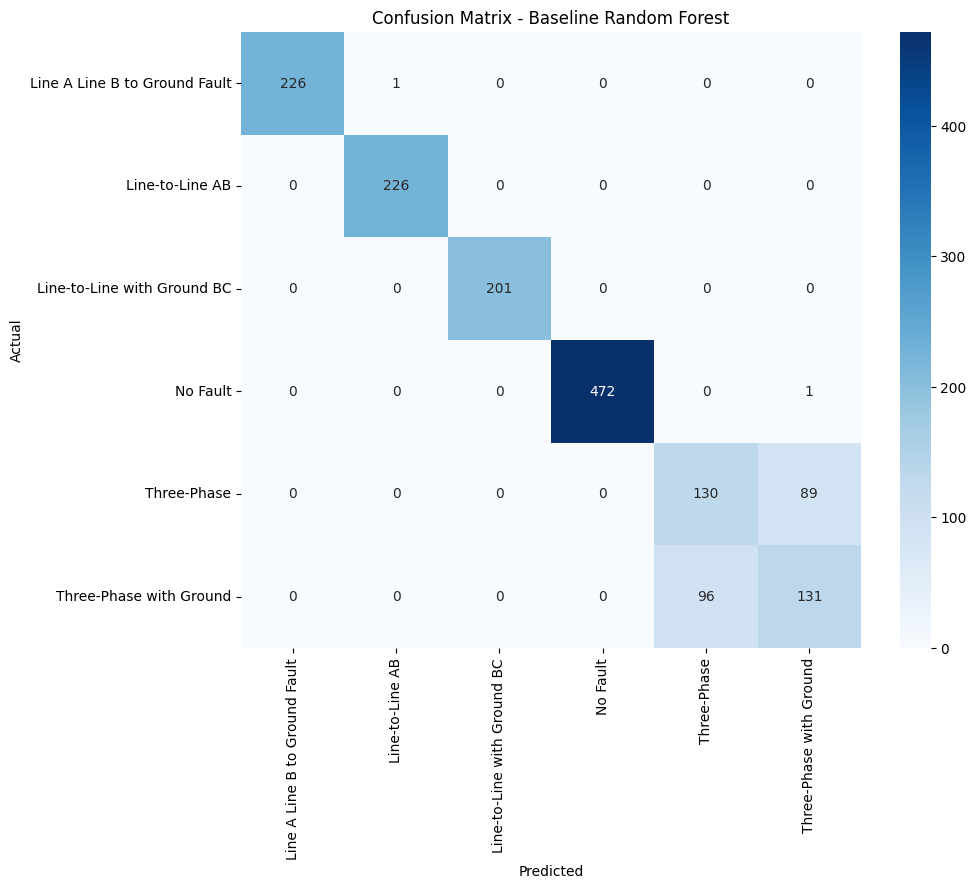

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, baseline_pred, labels=baseline_model.classes_)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=baseline_model.classes_,
    yticklabels=baseline_model.classes_,
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Random Forest")
plt.show()


## Mô hình Optimized - RF

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


In [31]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

best_metrics = {
    "accuracy": accuracy_score(y_test, best_pred),
    "f1_macro": f1_score(y_test, best_pred, average='macro'),
    "precision_macro": precision_score(y_test, best_pred, average='macro'),
    "recall_macro": recall_score(y_test, best_pred, average='macro'),
}

In [32]:
import joblib

gridsearch_artifacts = {
    "grid_search": grid_search,
    "best_model": best_model,
    "feature_cols": feature_cols,
    "param_grid": param_grid,
    "metrics": best_metrics
}

joblib.dump(gridsearch_artifacts, "rf_gridsearch.pkl")
print("Đã lưu Model")

Đã lưu Model


## Trực quan và Đánh giá Optimized

In [33]:
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

print("=== OPTIMIZED ACCURACY ===")
print(accuracy_score(y_test, best_pred))

print("\n=== OPTIMIZED REPORT ===")
print(classification_report(y_test, best_pred, zero_division=0))

=== OPTIMIZED ACCURACY ===
0.8798474253019708

=== OPTIMIZED REPORT ===
                               precision    recall  f1-score   support

Line A Line B to Ground Fault       1.00      1.00      1.00       227
              Line-to-Line AB       1.00      1.00      1.00       226
  Line-to-Line with Ground BC       1.00      1.00      1.00       201
                     No Fault       1.00      1.00      1.00       473
                  Three-Phase       0.57      0.58      0.58       219
      Three-Phase with Ground       0.59      0.58      0.58       227

                     accuracy                           0.88      1573
                    macro avg       0.86      0.86      0.86      1573
                 weighted avg       0.88      0.88      0.88      1573



### Confusion Matrix

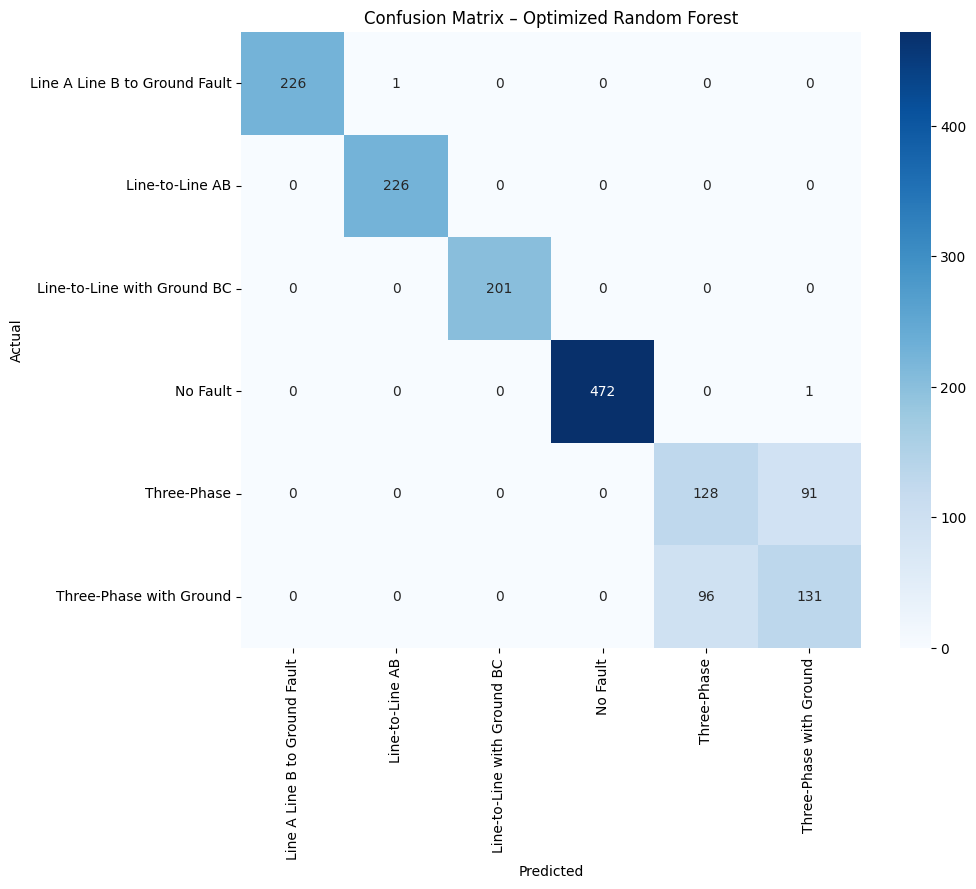

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_pred, labels=best_model.classes_)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_,
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Optimized Random Forest")
plt.show()

## Baseline vs Optimized

In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

baseline_pred = baseline_model.predict(X_test)
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

# Hàm tính metric
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average='macro'),
        "precision_macro": precision_score(y_true, y_pred, average='macro'),
        "recall_macro": recall_score(y_true, y_pred, average='macro'),
    }

baseline_metrics = compute_metrics(y_test, baseline_pred)
best_metrics = compute_metrics(y_test, best_pred)

baseline_metrics, best_metrics

({'accuracy': 0.8811188811188811,
  'f1_macro': 0.860602979899508,
  'precision_macro': 0.860596022264986,
  'recall_macro': 0.8606967276168024},
 {'accuracy': 0.8798474253019708,
  'f1_macro': 0.8591045189939942,
  'precision_macro': 0.8590778718788833,
  'recall_macro': 0.8591746576015816})

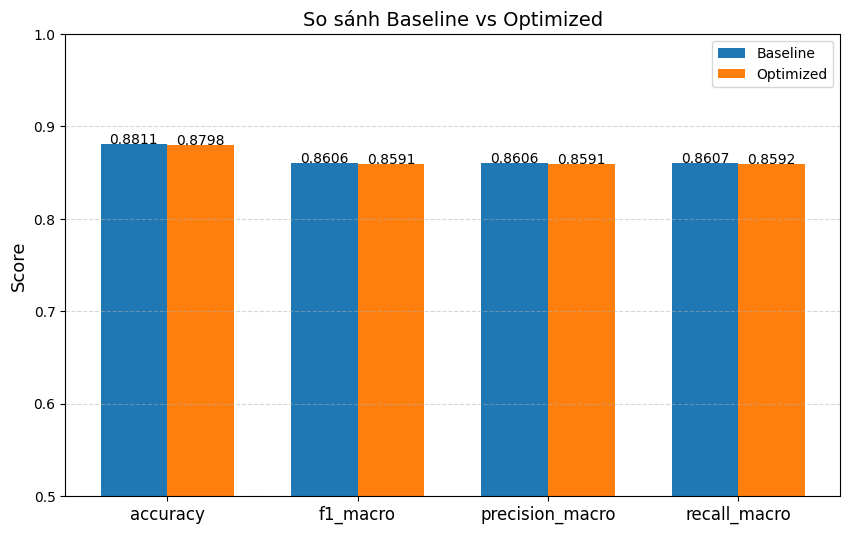

In [36]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

baseline_values = [baseline_metrics[m] for m in metrics]
best_values = [best_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
bars1 = plt.bar(x - width/2, baseline_values, width, label='Baseline')
bars2 = plt.bar(x + width/2, best_values, width, label='Optimized')

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.4f}",
             ha='center', fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.4f}",
             ha='center', fontsize=10)

plt.xticks(x, metrics, fontsize=12)
plt.ylabel('Score', fontsize=13)
plt.title('So sánh Baseline vs Optimized', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0.5, 1.00)  
plt.show()

## Test

In [37]:
import joblib
import pandas as pd
import numpy as np

# ===== Load models =====
rf_data = joblib.load('rf_baseline.pkl')
rf_model = rf_data["model"]

# random index
idx = np.random.choice(len(X_test), size=10, replace=False)

# lấy dữ liệu mẫu 
X_sample = X_test.iloc[idx]
y_true_sample = y_test.iloc[idx]

# dự đoán bằng Random Forest
y_pred_sample = rf_model.predict(X_sample)

# tạo DataFrame minh họa
demo_df = X_sample.copy()
demo_df["True"] = y_true_sample.values
demo_df["Pred"] = y_pred_sample
demo_df["Correct"] = demo_df["True"] == demo_df["Pred"]

demo_df

,Ia,Ib,Ic,Va,Vb,Vc,True,Pred,Correct
81,-621.110786,-11.677268,-35.549423,-0.197090,0.525933,-0.328843,Line-to-Line AB,Line-to-Line AB,True
7811,-67.956361,77.427562,-12.352273,-0.318537,-0.281641,0.600179,No Fault,No Fault,True
6425,54.404554,-2.227411,-55.468704,0.171062,0.427652,-0.598713,No Fault,No Fault,True
5380,835.425811,-660.671867,-73.832286,0.007217,-0.117809,0.110593,Three-Phase with Ground,Three-Phase with Ground,True
4427,-738.565070,-24.320260,763.174177,-0.046265,0.038288,0.007977,Three-Phase with Ground,Three-Phase,False
852,-852.180330,-39.433255,-13.693032,-0.033565,0.339933,-0.306368,Line-to-Line AB,Line-to-Line AB,True
804,-765.460606,-68.989580,22.887042,0.236533,-0.095554,-0.140980,Line-to-Line AB,Line-to-Line AB,True
7652,52.260970,18.452977,-73.639382,-0.081222,0.573939,-0.492716,No Fault,No Fault,True
7808,-66.965812,79.381281,-15.297373,-0.342826,-0.256493,0.599318,No Fault,No Fault,True
6733,-6.546289,-22.320471,25.671201,0.582136,-0.374260,-0.207876,No Fault,No Fault,True
